<!-- ============================================================ -->
<!-- NOTEBOOK HEADER — MLOps Introductory Course on GCP           -->
<!-- ============================================================ -->

<div style="border-bottom: 3px solid #4285F4; padding-bottom: 12px; margin-bottom: 20px;">

<div style="display: flex; align-items: center; justify-content: space-between;">
  <div>
    <img src="https://www.isae-supaero.fr/wp-content/uploads/2025/03/logo.svg" width="180">
  </div>
  <div style="text-align: right;">
    <img src="https://user-images.githubusercontent.com/63151412/167391313-4683cc69-2bf6-4597-b767-5c18e2bbbfa0.png" width="180">
  </div>
</div>

# Lab 01 — MLflow: Experiment Tracking

**Course:** MLOps Introductory Course on GCP · M2 Data Science · ISAE-SUPAERO  
**Lab created by:** Headmind Partners AI & Blockchain  
**Estimated duration:** ~2h30

</div>

## 📋 Lab Overview

### Learning Objectives

By the end of this lab, you will be able to:

1. **Launch and connect to an MLflow tracking server**
2. **Log parameters, metrics, and artifacts** to MLflow experiments
3. **Compare runs** using the MLflow UI
4. **Automate hyperparameter search** with Optuna, tracked by MLflow
5. **Register and version models** in the MLflow Model Registry
6. **Load a registered model** programmatically for inference

### Business Context

**Credit risk** is the risk that a borrower fails to repay a loan. Banks build credit-risk models to minimize expected losses, and machine learning classifiers can help predict whether a customer is likely to default.

In this lab you will work with the [German Credit Risk dataset](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data) (UCI), which contains anonymized profiles of 1 000 bank customers. Your job is to build a classifier that predicts whether a customer is **creditworthy** (`0`) or **at risk** (`1`).

### Why MLflow?

In production ML, tracking experiments is crucial. Without proper tracking:
- You can't reproduce results
- You lose track of which hyperparameters worked best
- Collaboration becomes chaotic
- Model deployment becomes error-prone

MLflow solves these problems by providing a unified platform for the ML lifecycle.

### Notebook Structure

| # | Section | Focus |
|---|---------|-------|
| 0 | Setup | Install dependencies, start MLflow server, connect |
| 1 | Data Exploration | Load data, EDA, class balance analysis |
| 2 | Feature Engineering | Identify and encode categorical features |
| 3 | Baseline Model + MLflow Logging | Train a default Random Forest, log everything to MLflow |
| 4 | Manual Tuning + MLflow Comparison | Tweak hyperparameters by hand, compare runs in the UI |
| 5 | Automated Tuning with Optuna | Use Optuna for systematic search, nested MLflow runs |
| 6 | Model Registry | Register, version, and load the best model |

### How to Read This Notebook

- **`# TODO`** — Code you need to write. Look for the `######` delimiters.
- **`✏️ Question`** — A conceptual question. Write your answer in the markdown cell below it.
- Cells **without** a TODO are provided — read them, run them, and make sure you understand them.
- Documentation links are provided in 📖 callouts whenever a new API is introduced.

---
## 0 · Setup

### 0.1 Install dependencies

Make sure that you have a virtual environment created for this lab (See README.md installation guide - Step 2). Select this venv for the notebook kernel.

In [1]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### 0.2 Imports

In [5]:
import pickle
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import mlflow
from mlflow import MlflowClient
import optuna

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42          # reproducibility
TEST_SIZE = 0.20           # 80/20 split
VAL_SIZE = 0.20            # 20 % of training set for validation

print(f"MLflow version: {mlflow.__version__}")
print(f"Optuna version: {optuna.__version__}")

MLflow version: 3.10.1
Optuna version: 4.7.0


### 0.3 Start the MLflow Tracking Server

Before running the rest of this notebook, **open a terminal**, activate this lab's virtual environment and start a local MLflow server:

```bash
mlflow server --host 127.0.0.1 --port 8080
```

Then open the UI in your browser at [http://127.0.0.1:8080](http://127.0.0.1:8080).

> 📖 **Docs:** [MLflow Tracking Server](https://mlflow.org/docs/latest/tracking/server.html)

💡 **Tip**: Keep this terminal open throughout the lab. The MLflow server must be running to track experiments.

In [6]:
##############################  TODO  ##############################
# Set host and port to match the server you just started.
MLFLOW_HOST = "127.0.0.1"   # TODO
MLFLOW_PORT = "8080"   # TODO
####################################################################

TRACKING_URI = f"http://{MLFLOW_HOST}:{MLFLOW_PORT}"
mlflow.set_tracking_uri(TRACKING_URI)
print(f"Tracking URI set to: {TRACKING_URI}")

Tracking URI set to: http://127.0.0.1:8080


---
## 1 · Data Exploration

### 1.1 Load the dataset

In [7]:
df = pd.read_parquet("data/dataset.parquet")
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 21)


,checking_account_status,duration_month,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence_since,property,age,other_installment_plans,housing,existing_credits_count,job,dependents_count,telephone,foreign_worker,class
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,A65,.. >= 7 years,4,male : single,none,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,A61,1 <= ... < 4 years,2,female : divorced/separated/married,none,2,real estate,22,none,own,1,skilled employee / official,1,none,yes,2
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,A61,4 <= ... < 7 years,2,male : single,none,3,real estate,49,none,own,1,unskilled - resident,2,none,yes,1
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,A61,4 <= ... < 7 years,2,male : single,guarantor,4,building society savings agreement/life insurance,45,none,for free,1,skilled employee / official,2,none,yes,1
4,< 0 DM,24,delay in paying off in the past,car (new),4870,A61,1 <= ... < 4 years,3,male : single,none,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,2


In [ ]:
df.info()

### 1.2 Identify the target

The goal is to predict whether a bank should grant credit to a customer.

**✏️ TODO:** Look at the column names and values. Which column is the target?

In [8]:
##############################  TODO  ##############################
# Replace the empty string with the name of the target column.
target_field = "class"  # TODO
####################################################################

In [9]:
# Rename and remap: 1 → 0 (creditworthy), 2 → 1 (at risk)
df = df.rename(columns={target_field: "risk"})
df["risk"] = df["risk"].map({1: 0, 2: 1})

# Separate features and target
y = df["risk"]
X = df.drop(columns=["risk"])

print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")
print(f"Target distribution:\n{y.value_counts(normalize=True).round(3)}")

Features: 20  |  Samples: 1000
Target distribution:
0    0.7
1    0.3
Name: risk, dtype: float64


This is a **binary classification** problem:
- `risk = 0` → customer is creditworthy
- `risk = 1` → customer is at risk of default

### 1.3 Exploratory Data Analysis

#### Correlation matrix (numeric features only)

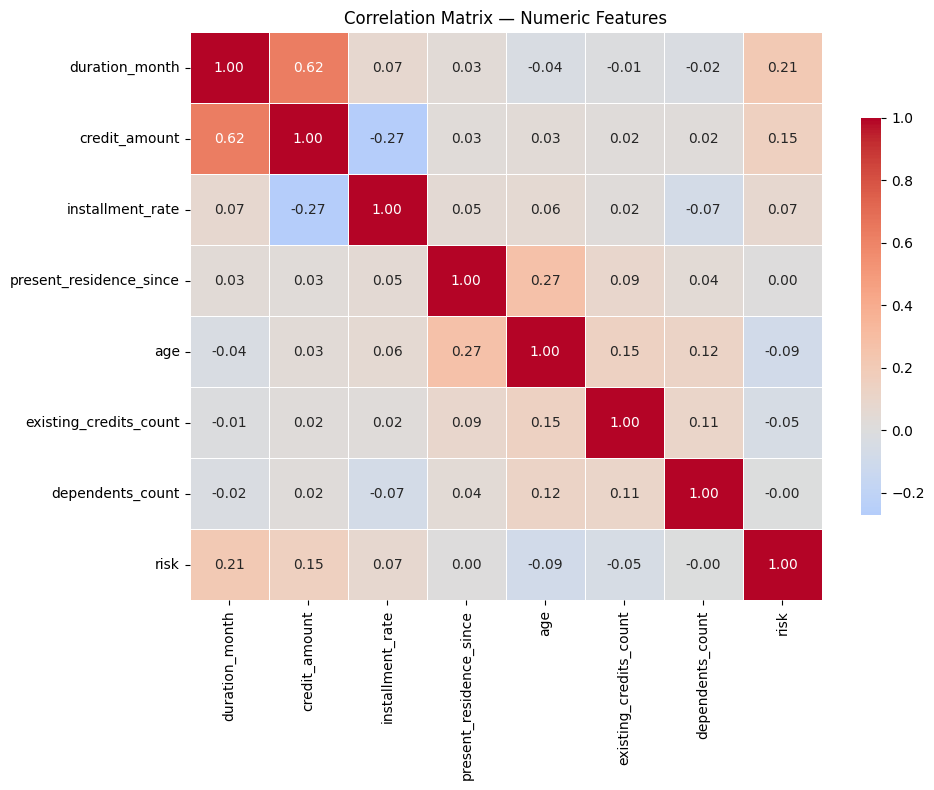

In [10]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5,
            cbar_kws={"shrink": 0.7}, center=0)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

#### Class distribution

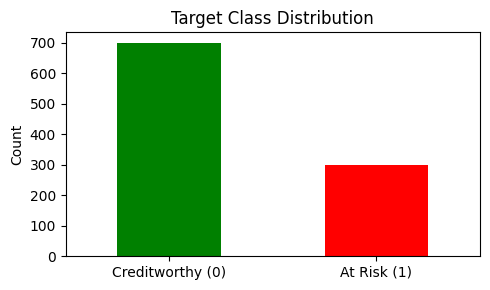

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
y.value_counts().plot(kind="bar", color=["g", "r"], ax=ax)
ax.set_xticklabels(["Creditworthy (0)", "At Risk (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Target Class Distribution")
plt.tight_layout()
plt.show()

**✏️ Question 1 — Class imbalance**

a) Is this dataset balanced? Compute the exact class proportions.  
b) What risks does class imbalance pose for a classifier?  
c) Name **two** techniques you could use to handle imbalance (you don't need to implement them here).

---
*Your answer:*

a) No, the dataset is imbalanced, with 70% of clients classified as creditworthy and 30% classified as at risk.  

b) This poses a risk because the classifier may become biased toward the majority class (creditworthy clients), leading to poorer performance in identifying the minority class (at-risk clients), such as lower recall and F1-score.  

c) Two techniques to handle class imbalance are:

- Stratified sampling, to ensure that the train and test sets maintain the same class proportions as the original dataset.

- Oversampling the minority class (clients at risk) to increase their representation in the training data.

---

**✏️ Question 2 — From binary to multi-level risk**

In practice, banks use more granular risk categories (e.g., AAA, AA, A, BBB, …). Given a binary classifier that outputs probabilities, how could you derive *n* risk levels from it? Give a concrete example with n = 4.

---
*Your answer:*

A binary classifier outputs the probability that a client is at risk.  
To derive n risk levels, we can divide the predicted probabilities into n groups using quantiles.

Example with n = 4 risk levels (quartiles):

- Level 1 (Very low risk): probabilities in the 0–25% quantile  
- Level 2 (Low risk): probabilities in the 25–50% quantile  
- Level 3 (Medium risk): probabilities in the 50–75% quantile  
- Level 4 (High risk): probabilities in the 75–100% quantile  

Each client is assigned to a risk category according to the quantile of their predicted probability.


---

---
## 2 · Feature Engineering

We need to encode categorical features before training a tree-based model.

> 📖 **Docs:** [`sklearn.preprocessing.OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)

In [12]:
# Separate numeric and categorical columns
numeric_feat = X.select_dtypes(include="number").columns.tolist()
categorical_feat = X.select_dtypes(exclude="number").columns.tolist()

print(f"Numeric features ({len(numeric_feat)}): {numeric_feat}")
print(f"Categorical features ({len(categorical_feat)}): {categorical_feat}")

Numeric features (7): ['duration_month', 'credit_amount', 'installment_rate', 'present_residence_since', 'age', 'existing_credits_count', 'dependents_count']
Categorical features (13): ['checking_account_status', 'credit_history', 'purpose', 'savings_account', 'employment_duration', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


**✏️ TODO:** Create a OneHotEncoder instance

In [15]:
##############################  TODO  ##############################
# Using sklearn's OneHotEncoder:
#   1. Create a OneHotEncoder instance (use handle_unknown="ignore"
#      so the encoder won't crash on unseen categories at inference).
#   2. fit_transform it on X[categorical_feat].
#   3. Build a DataFrame X_enc that combines the encoded columns
#      with the original numeric columns.
#
# Useful methods:
#   encoder.fit_transform(data)          → sparse/dense array
#   sparse_array.toarray()               → convert to dense numpy array
#   encoder.get_feature_names_out(input_features=...)   → column names

onehot_encoder = OneHotEncoder(handle_unknown="ignore")  # TODO: create the encoder
X_enc_array = onehot_encoder.fit_transform(X[categorical_feat])  # TODO: fit_transform on categorical columns

X_enc = pd.DataFrame( # TODO: build the final DataFrame.
    X_enc_array.toarray(),
    columns=onehot_encoder.get_feature_names_out(input_features=categorical_feat),
)
X_enc[numeric_feat] = X[numeric_feat].values
####################################################################

print(f"Encoded feature matrix shape: {X_enc.shape}")
X_enc.head()

Encoded feature matrix shape: (1000, 61)


,checking_account_status_0 <= ... < 200 DM,checking_account_status_< 0 DM,checking_account_status_>= 200 DM / salary assignments for at least 1 year,checking_account_status_no checking account,credit_history_all credits at this bank paid back duly,credit_history_critical account/ other credits existing (not at this bank),credit_history_delay in paying off in the past,credit_history_existing credits paid back duly till now,credit_history_no credits taken/ all credits paid back duly,purpose_business,purpose_car (new),purpose_car (used),purpose_domestic appliances,purpose_education,purpose_furniture/equipment,purpose_others,purpose_radio/television,purpose_repairs,purpose_retraining,savings_account_A61,savings_account_A62,savings_account_A63,savings_account_A64,savings_account_A65,employment_duration_.. >= 7 years,...,property_building society savings agreement/life insurance,"property_car or other, not in attribute 6",property_real estate,property_unknown / no property,other_installment_plans_bank,other_installment_plans_none,other_installment_plans_stores,housing_for free,housing_own,housing_rent,job_management/ self-employed/highly qualified employee/ officer,job_skilled employee / official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,telephone_none,"telephone_yes, registered under the customers name",foreign_worker_no,foreign_worker_yes,duration_month,credit_amount,installment_rate,present_residence_since,age,existing_credits_count,dependents_count
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,6,1169,4,4,67,2,1
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,48,5951,2,2,22,1,1
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,12,2096,2,3,49,1,2
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,42,7882,2,4,45,1,2
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,24,4870,3,4,53,2,2


In [14]:
# Save the encoder — we will log it as an MLflow artifact later
with open("data/one_hot_encoder.pkl", "wb") as f:
    pickle.dump(onehot_encoder, f)
print("Encoder saved to data/one_hot_encoder.pkl")

Encoder saved to data/one_hot_encoder.pkl


**✏️ Question 3 — One-hot encoding**

a) In one sentence, what does one-hot encoding do?  
b) How would `['Cat', 'Cat', 'Dog', 'Cat', 'Bird', 'Dog']` be transformed?  

---
*Your answer:*

a) OneHotEncoding transforms categorical features into binary (0/1) columns ( one per unique category) where only the column matching the present category is marked 1 and the rest are 0.

b) With the categories `Bird`, `Cat`, and `Dog`, the one-hot encoded vectors are:

- `Cat` → `[0, 1, 0]`
- `Cat` → `[0, 1, 0]`
- `Dog` → `[0, 0, 1]`
- `Cat` → `[0, 1, 0]`
- `Bird` → `[1, 0, 0]`
- `Dog` → `[0, 0, 1]`

---

---
## 3 · Baseline Model + MLflow Logging

### 3.1 Train / Test Split

> 📖 **Docs:** [`sklearn.model_selection.train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

**✏️ TODO:** Split `X_enc` and `y` into training and test sets. Use `stratify=y` so that the class proportions are preserved in both sets.

In [16]:
##############################  TODO  ##############################
# Use train_test_split with test_size=TEST_SIZE, stratify=y,
# and random_state=RANDOM_STATE.
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)  # TODO
####################################################################

print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")
print(f"Train risk ratio: {y_train.mean():.3f}  |  Test risk ratio: {y_test.mean():.3f}")

Train: 800 samples  |  Test: 200 samples
Train risk ratio: 0.300  |  Test risk ratio: 0.300


### 3.2 Train a baseline Random Forest (default hyperparameters)

> 📖 **Docs:** [`sklearn.ensemble.RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [17]:
rf_baseline = RandomForestClassifier(random_state=RANDOM_STATE)
rf_baseline.fit(X_train, y_train)

y_pred_proba = rf_baseline.predict_proba(X_test)[:, 1]
y_pred = rf_baseline.predict(X_test)

print(f"Baseline AUC:      {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Baseline F1-score: {f1_score(y_test, y_pred):.4f}")

Baseline AUC:      0.7805
Baseline F1-score: 0.5102


### 3.3 Log the baseline run to MLflow

This is the core of this lab: we will log **parameters**, **metrics**, the **model**, and an **artifact** (our encoder) to MLflow.

> 📖 **Key MLflow functions:**
> - [`mlflow.set_experiment()`](https://mlflow.org/docs/latest/python_api/mlflow.html#mlflow.set_experiment)
> - [`mlflow.start_run()`](https://mlflow.org/docs/latest/python_api/mlflow.html#mlflow.start_run)
> - [`mlflow.log_param()`](https://mlflow.org/docs/latest/python_api/mlflow.html#mlflow.log_param) / [`mlflow.log_params()`](https://mlflow.org/docs/latest/python_api/mlflow.html#mlflow.log_params)
> - [`mlflow.log_metric()`](https://mlflow.org/docs/latest/python_api/mlflow.html#mlflow.log_metric)
> - [`mlflow.sklearn.log_model()`](https://mlflow.org/docs/latest/python_api/mlflow.sklearn.html#mlflow.sklearn.log_model)
> - [`mlflow.log_artifact()`](https://mlflow.org/docs/latest/python_api/mlflow.html#mlflow.log_artifact)

In [20]:
import os
os.environ["NO_PROXY"] = "localhost,127.0.0.1"
os.environ["no_proxy"] = "localhost,127.0.0.1"

In [21]:
EXPERIMENT_NAME = "credit-risk-classification-v1"
mlflow.set_experiment(experiment_name=EXPERIMENT_NAME)

with mlflow.start_run(run_name="baseline_random_forest"):
    # --- Log hyperparameters ---
    params = rf_baseline.get_params()
    mlflow.log_param("n_estimators", params["n_estimators"])
    mlflow.log_param("max_depth", params["max_depth"])
    mlflow.log_param("min_samples_leaf", params["min_samples_leaf"])
    mlflow.log_param("bootstrap", params["bootstrap"])

    # --- Log metrics ---
    mlflow.log_metric("auc", roc_auc_score(y_test, y_pred_proba))
    mlflow.log_metric("f1_score", f1_score(y_test, y_pred))

    # --- Log the model ---
    mlflow.sklearn.log_model(
        rf_baseline,
        name="model",
        registered_model_name="credit-risk-rf",
    )

    # --- Log the encoder as an artifact ---
    mlflow.log_artifact(local_path="data/one_hot_encoder.pkl")

    print("✅ Baseline run logged to MLflow.")

2026/03/09 10:22:50 INFO mlflow.tracking.fluent: Experiment with name 'credit-risk-classification-v1' does not exist. Creating a new experiment.
2026/03/09 10:22:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'credit-risk-rf'.
2026/03/09 10:22:54 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: credit-risk-rf, version 1
Created version '1' of model 'credit-risk-rf'.


✅ Baseline run logged to MLflow.
🏃 View run baseline_random_forest at: http://127.0.0.1:8080/#/experiments/1/runs/c35e9819ee1f4c06bf10dbcd1da6e584
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1


**👉 Now open the MLflow UI** ([http://127.0.0.1:8080](http://127.0.0.1:8080)) and explore your run.

**✏️ Question 4 — Navigate the MLflow UI**

Using the MLflow UI, answer the following:

a) What are the default values for `n_estimators`, `max_depth`, and `bootstrap` logged for the baseline run?  
b) Describe the path you followed in the UI to find them (e.g., *Experiments → … → …*).

---
*Your answer:*

a) The model uses `n_estimators = 100`, `max_depth = None`, and `bootstrap = True`.

b) Experiments → credit-risk-classification-v1 → Runs → baseline_random_forest → Overview → Metrics / Parameters


---

---
## 4 · Manual Tuning + MLflow Comparison

Now let's see if we can improve the baseline by **manually** adjusting a few hyperparameters.

**✏️ TODO:** Choose your own values for the hyperparameters below. Run the cell **at least 2–3 times** with different configurations, then compare all runs in the MLflow UI.

> 💡 **Tip:** After running the cell multiple times, go to the MLflow UI, select multiple runs, and click **Compare** to see a side-by-side table of parameters and metrics.

In [26]:
##############################  TODO  ##############################
# Try different values. Run this cell multiple times, changing
# the values each time to explore the hyperparameter space.
manual_params = {
    "n_estimators": 100,          # TODO: try 50, 100, 200, 500...
    "max_depth": 5,            # TODO: try 3, 5, 10, None...
    "min_samples_leaf": 5,        # TODO: try 1, 5, 10...
    "bootstrap": False,            # TODO: try True, False
}
####################################################################

rf_manual = RandomForestClassifier(**manual_params, random_state=RANDOM_STATE)
rf_manual.fit(X_train, y_train)

y_pred_proba = rf_manual.predict_proba(X_test)[:, 1]
y_pred = rf_manual.predict(X_test)
auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

mlflow.set_experiment(experiment_name=EXPERIMENT_NAME)
with mlflow.start_run(run_name="manual_tuning"):
    mlflow.log_params(manual_params)
    mlflow.log_metric("auc", auc)
    mlflow.log_metric("f1_score", f1)
    mlflow.sklearn.log_model(
        rf_manual,
        name="model",
        registered_model_name="credit-risk-rf",
    )
    mlflow.log_artifact(local_path="data/one_hot_encoder.pkl")

print(f"AUC: {auc:.4f}  |  F1: {f1:.4f}")
print("✅ Manual tuning run logged.")

2026/03/09 10:31:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'credit-risk-rf' already exists. Creating a new version of this model...
2026/03/09 10:31:57 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: credit-risk-rf, version 6
Created version '6' of model 'credit-risk-rf'.


🏃 View run manual_tuning at: http://127.0.0.1:8080/#/experiments/1/runs/3c880b6556d9488fbd9ae22f309d812b
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1
AUC: 0.7758  |  F1: 0.2703
✅ Manual tuning run logged.


**✏️ Question 5 — Manual tuning observations**

a) Which hyperparameter combination gave you the best F1-score so far?  
b) Why is manual tuning tedious and potentially unreliable?

---
*Your answer:*

a) By comparing the different runs, the first run with the default parameters gave the best F1-score so far, with a value of `0.51`.

b) Manual tuning is tedious and potentially unreliable because the hyperparameter search space is very large, and the best values depend strongly on the dataset. As a result, there is no standard set of hyperparameters that works best in every case.

---

---
## 5 · Automated Tuning with Optuna

[Optuna](https://optuna.readthedocs.io/en/stable/) is an automatic hyperparameter optimization framework. It uses smart search strategies (e.g., Tree-structured Parzen Estimators) instead of brute-force grid search.

> 📖 **Docs:** [Optuna — Key Concepts](https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/001_first.html)

### 5.1 Create a validation split

We split the **training set** further into train and validation. The validation set is used by Optuna to score each trial. The test set remains untouched until final evaluation.

In [27]:
X_train_opt, X_val, y_train_opt, y_val = train_test_split(
    X_train, y_train,
    test_size=VAL_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)
print(f"Optuna train: {X_train_opt.shape[0]}  |  Validation: {X_val.shape[0]}  |  Test: {X_test.shape[0]}")

Optuna train: 640  |  Validation: 160  |  Test: 200


**✏️ Question 6 — Train / Validation / Test**

a) Explain in your own words the role of each split: train, validation, and test.  
b) What happens if the validation set and test set overlap?

---
*Your answer:*

a)  
- **Train**: used to train the model.  
- **Validation**: used to tune and choose the best hyperparameters.  
- **Test**: used to evaluate the final performance of the selected model on unseen data.

b) If the validation set and test set overlap, the evaluation is no longer reliable because information from the test set indirectly influences model selection. This can lead to overfitting to the test data and overly optimistic performance results.


---

### 5.2 Define the Optuna objective

**✏️ TODO:** Fill in the hyperparameter search ranges. Use the [Optuna `suggest_*` API](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.trial.Trial.html):
- `trial.suggest_int(name, low, high)`
- `trial.suggest_float(name, low, high)`
- `trial.suggest_categorical(name, choices)`

In [33]:
def objective(trial):
    """Optuna objective: train a RF with suggested params, return F1."""
    with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
    ##############################  TODO  ##############################
        # Define the hyperparameter search space.
        params = {
            "n_estimators":    trial.suggest_int("n_estimators", low=50, high=1000),
            "max_depth":       trial.suggest_int("max_depth", low=1, high=20),
            "max_features":    trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            "min_samples_leaf": trial.suggest_float("min_samples_leaf", low=0.01, high=0.5),
        }
        ####################################################################

        clf = RandomForestClassifier(**params, random_state=RANDOM_STATE)
        clf.fit(X_train_opt, y_train_opt)

        y_val_pred = clf.predict(X_val)
        y_val_proba = clf.predict_proba(X_val)[:, 1]

        score = f1_score(y_val, y_val_pred)

        # Log to MLflow (nested run — each trial becomes a child run)
        mlflow.log_params(params)
        mlflow.log_metric("val_f1_score", score)
        mlflow.log_metric("val_auc", roc_auc_score(y_val, y_val_proba))

    return score

### 5.3 Run the optimization

We run 30 trials within a parent MLflow run. Each trial is logged as a nested child run.

In [34]:
study = optuna.create_study(direction="maximize")

mlflow.set_experiment(experiment_name=EXPERIMENT_NAME)

with mlflow.start_run(run_name="optuna_search"):
    study.optimize(objective, n_trials=30, timeout=600)

best_params = study.best_trial.params
print(f"\n🏆 Best trial F1: {study.best_trial.value:.4f}")
print(f"Best params: {best_params}")

[I 2026-03-09 11:05:09,103] A new study created in memory with name: no-name-0e1a1bf6-cab8-49b3-823e-19631b5557b8
[I 2026-03-09 11:05:09,799] Trial 0 finished with value: 0.0 and parameters: {'n_estimators': 447, 'max_depth': 1, 'max_features': 'sqrt', 'min_samples_leaf': 0.048205073124286096}. Best is trial 0 with value: 0.0.


🏃 View run trial_0 at: http://127.0.0.1:8080/#/experiments/1/runs/04e4321b05fa4a37b707478fbf4c73f5
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1


[I 2026-03-09 11:05:10,634] Trial 1 finished with value: 0.0 and parameters: {'n_estimators': 759, 'max_depth': 19, 'max_features': 'sqrt', 'min_samples_leaf': 0.09790619160897904}. Best is trial 0 with value: 0.0.


🏃 View run trial_1 at: http://127.0.0.1:8080/#/experiments/1/runs/20565ff21eb24f84860e1b9458cc5d0e
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1


[I 2026-03-09 11:05:11,291] Trial 2 finished with value: 0.0 and parameters: {'n_estimators': 449, 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 0.2981181164046961}. Best is trial 0 with value: 0.0.


...

🏃 View run trial_27 at: http://127.0.0.1:8080/#/experiments/1/runs/d8eb22bb88b3491fb12cecce845b787f
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1


[I 2026-03-09 11:05:35,267] Trial 28 finished with value: 0.0 and parameters: {'n_estimators': 538, 'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 0.3302352092545606}. Best is trial 14 with value: 0.4.


🏃 View run trial_28 at: http://127.0.0.1:8080/#/experiments/1/runs/29bd3707d0ed431b807b8413e7825e02
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1


[I 2026-03-09 11:05:36,454] Trial 29 finished with value: 0.3855421686746988 and parameters: {'n_estimators': 692, 'max_depth': 17, 'max_features': None, 'min_samples_leaf': 0.05183696898635265}. Best is trial 14 with value: 0.4.


🏃 View run trial_29 at: http://127.0.0.1:8080/#/experiments/1/runs/4d4c15b8de92486fb4abfb52df903abd
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1
🏃 View run optuna_search at: http://127.0.0.1:8080/#/experiments/1/runs/3148818ec4d94d8caf97251ccf799110
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1

🏆 Best trial F1: 0.4000
Best params: {'n_estimators': 714, 'max_depth': 15, 'max_features': None, 'min_samples_leaf': 0.011008935127847182}


### 5.4 Retrain with the best parameters on full training data

Now that Optuna has found the best hyperparameters, we retrain on the **combined** train + validation sets and evaluate on the **held-out test set**.

In [35]:
# Recombine train + validation
X_train_full = pd.concat([X_train_opt, X_val])
y_train_full = pd.concat([y_train_opt, y_val])

# Train final model
rf_best = RandomForestClassifier(**best_params, random_state=RANDOM_STATE)
rf_best.fit(X_train_full, y_train_full)

# Evaluate on test set
y_test_pred = rf_best.predict(X_test)
y_test_proba = rf_best.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, y_test_proba)
final_f1 = f1_score(y_test, y_test_pred)

print(f"Final Test AUC:      {final_auc:.4f}")
print(f"Final Test F1-score: {final_f1:.4f}")

Final Test AUC:      0.7602
Final Test F1-score: 0.5283


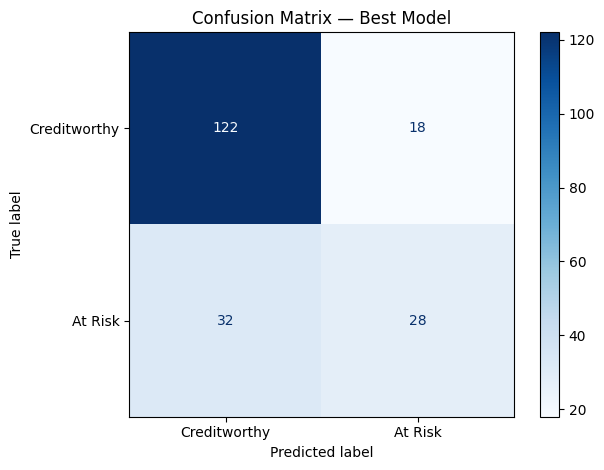

In [36]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Creditworthy", "At Risk"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Best Model")
plt.tight_layout()
plt.show()

In [37]:
# Log the final best model to MLflow
mlflow.set_experiment(experiment_name=EXPERIMENT_NAME)

with mlflow.start_run(run_name="best_model_final_eval"):
    mlflow.log_params(best_params)
    mlflow.log_metric("test_auc", final_auc)
    mlflow.log_metric("test_f1_score", final_f1)

    mlflow.sklearn.log_model(
        rf_best,
        artifact_path="model",
        registered_model_name="credit-risk-rf-tuned",
    )
    mlflow.log_artifact(local_path="data/one_hot_encoder.pkl")

    # Save the confusion matrix plot as an artifact
    fig, ax = plt.subplots()
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Creditworthy", "At Risk"]).plot(ax=ax, cmap="Blues")
    fig.savefig("data/confusion_matrix.png", dpi=100, bbox_inches="tight")
    plt.close(fig)
    mlflow.log_artifact("data/confusion_matrix.png")

    print("✅ Best model logged with confusion matrix artifact.")

2026/03/09 11:06:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 11:06:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'credit-risk-rf-tuned'.
2026/03/09 11:06:35 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: credit-risk-rf-tuned, version 1
Created version '1' of model 'credit-risk-rf-tuned'.


✅ Best model logged with confusion matrix artifact.
🏃 View run best_model_final_eval at: http://127.0.0.1:8080/#/experiments/1/runs/c03e57e747074c5bbfb2dc5a34900235
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1


---
## 6 · Model Registry

The MLflow **Model Registry** lets you manage model versions and assign lifecycle stages like *Staging* or *Production*.

> 📖 **Docs:** [MLflow Model Registry](https://mlflow.org/docs/latest/model-registry.html)

### 6.1 Load a model from Model Registry

**✏️ TODO:** Load the model using its model URI. The model URI is made from the model name and the model version (Hint: check the **Models** tab in the MLflow UI).
> 📖 **Docs:** [`mlflow.sklearn.load_model`](https://mlflow.org/docs/latest/api_reference/python_api/mlflow.sklearn.html#mlflow.sklearn.load_model)

In [38]:
##############################  TODO  ##############################
# Load and test the model using the model URI
MODEL_NAME = "credit-risk-rf-tuned" # TODO
MODEL_VERSION = 1 # TODO
loaded_model = mlflow.sklearn.load_model(f"models:/{MODEL_NAME}/{MODEL_VERSION}")
####################################################################

preds = loaded_model.predict(X_test[:5])
print(f"Sample predictions: {preds}")

Sample predictions: [0 0 1 0 0]


### 6.2 Manage model versions with aliases

Modern MLflow (>= 2.9) uses **model aliases** instead of the deprecated "Stages" system. An alias is a mutable, named reference to a specific model version — for example, you might tag your best model version as `champion`.

> 📖 **Docs:** [Model aliases](https://mlflow.org/docs/latest/model-registry.html#deploy-and-organize-models-with-aliases-and-tags)

In [39]:
client = MlflowClient()

MODEL_VERSION_ALIAS = "champion"

client.set_registered_model_alias(
    name=MODEL_NAME,
    alias=MODEL_VERSION_ALIAS,
    version=MODEL_VERSION,
)
print(f"✅ Alias {MODEL_VERSION_ALIAS} set on {MODEL_NAME} v{MODEL_VERSION}")

✅ Alias champion set on credit-risk-rf-tuned v1


### 6.3 Load a model by alias

Now anyone can load the production model using the alias, without needing to know the specific version number or run ID:

In [40]:
# Load the model using its alias
champion_model = mlflow.sklearn.load_model(f"models:/{MODEL_NAME}@{MODEL_VERSION_ALIAS}")

preds = champion_model.predict(X_test[:5])
print(f"Champion model predictions: {preds}")
print("\n🎉 You have successfully loaded a model from the MLflow Registry!")

Champion model predictions: [0 0 1 0 0]

🎉 You have successfully loaded a model from the MLflow Registry!


**✏️ Question 7 — Why use a Model Registry?**

In a team of data scientists, why is a model registry useful compared to simply saving model files to a shared folder? Think about versioning, reproducibility, and deployment.

---
*Your answer:*

A model registry is more useful than simply saving model files in a shared folder because it gives the team a clear and organized way to manage models. Different team members can see the models in one interface, along with their metrics, hyperparameters, and versions, without having to search through long notebooks or many files. It also improves reproducibility, since each model version is tracked and linked to a specific run or experiment. Finally, it helps deployment because the team can easily promote a new model, keep older versions, or roll back to a previous one if needed. .




---

---
## Summary

In this lab, you learned to:

| Step | What you did | MLflow feature used |
|------|-------------|---------------------|
| Setup | Start a tracking server and connect to it | `mlflow server`, `set_tracking_uri()` |
| Baseline | Train a model and log params/metrics/model | `log_param()`, `log_metric()`, `sklearn.log_model()` |
| Manual tuning | Compare runs side by side | MLflow UI comparison view |
| Optuna | Automate search with nested runs | `start_run()` context nesting |
| Artifacts | Log files alongside runs | `log_artifact()` |
| Registry | Version and alias models | `MlflowClient.set_registered_model_alias()` |

**Next lab:** We will move from local MLflow to **Vertex AI on GCP** to track experiments and deploy models in the cloud.